# **TFM PAU BUJONS LARIO - Spiking Neural Networks YOLO-Based Model for Early Wildfire Detection in Ground and Aerial Images using UAVs**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#MODIFICAR D'ACORD A LA RUTA DE LES TEVES CARPETES
%cd /content/drive/My Drive/TFM

Mounted at /content/drive
/content/drive/My Drive/TFM


In [ ]:
!pip install -r requirements.txt

!pip install -e SpikeYOLO/
!python SpikeYOLO/setup.py install
!pip install torchinfo
!pip install spikingjelly
!pip install codecarbon
!pip install -U ultralytics

Obtaining file:///content/drive/MyDrive/TFM/SpikeYOLO
  Preparing metadata (setup.py) ... done
  Running setup.py develop for ultralytics
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``s

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.6 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.0.197
    Uninstalling ultralytics-8.0.197:
      Successfully uninstalled ultralytics-8.0.197


In [1]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
import shutil
import random
import codecarbon
import pandas as pd
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

# CREATE SMALL TESTING DATASET


In [ ]:
#CREATE SMALL DATASET

image_dir = "/obs/pbujons/Desktop/Master/Setembre 2025 - Gener 2026/TFM/data/D-Fire Dataset for Smoke and Fire Detection/data/train/images"
label_dir = "/obs/pbujons/Desktop/Master/Setembre 2025 - Gener 2026/TFM/data/D-Fire Dataset for Smoke and Fire Detection/data/train/labels"
output_dir = "/obs/pbujons/Desktop/Master/Setembre 2025 - Gener 2026/TFM/data/Small-Data-Test"

os.makedirs(output_dir, exist_ok=True)

out_fire = os.path.join(output_dir, "fire")
out_smoke = os.path.join(output_dir, "smoke")
out_none = os.path.join(output_dir, "none")

for d in [out_fire, out_smoke, out_none]:
    os.makedirs(d, exist_ok=True)

count = {"fire": 0, "smoke": 0, "none": 0}
max_per_class = 10

for img in sorted(os.listdir(image_dir)):

    if not img.endswith(".jpg"):
        continue

    label_path = os.path.join(label_dir, img.replace(".jpg", ".txt"))
    img_path = os.path.join(image_dir, img)

    # Default category
    category = "none"

    # Read labels if file exists
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()

        if len(lines) > 0:
            classes = [int(line.split()[0]) for line in lines]

            # Class detection: adjust if your classes are different
            if 0 in classes:
                category = "fire"
            elif 1 in classes:
                category = "smoke"

    # Check if we already reached the quota
    if count[category] >= max_per_class:
        continue

    # Copy image + label
    shutil.copy(img_path, os.path.join(output_dir, category, img))

    if os.path.exists(label_path):
        shutil.copy(label_path, os.path.join(output_dir, category, img.replace(".jpg", ".txt")))

    count[category] += 1

    # Stop if all categories are full
    if all(count[c] >= max_per_class for c in count):
        break

print("Done!")
print(count)


Done!
{'fire': 10, 'smoke': 10, 'none': 10}


## CREATE VALIDATION AND TEST SETS OUT OF THE TRAIN IMAGES

In [ ]:
# === USER SETTINGS ===
# Folder with all training images
images_dir = r"/content/drive/MyDrive/TFM/dataset/D-Fire/train/images"          # e.g. "data/images/train"
# Folder with all training labels
labels_dir = r"/content/drive/MyDrive/TFM/dataset/D-Fire/train/labels"          # e.g. "data/labels/train"

# Where to put validation images/labels
val_images_dir = r"/content/drive/MyDrive/TFM/dataset/D-Fire/val/images"  # e.g. "data/images/val"
val_labels_dir = r"/content/drive/MyDrive/TFM/dataset/D-Fire/val/labels"  # e.g. "data/labels/val"

# How many images to move to validation
n_val = 1722

# Set random seed for reproducibility (optional)
random.seed(42)

# ======================

os.makedirs(val_images_dir, exist_ok=True)
os.makedirs(val_labels_dir, exist_ok=True)

# Valid image extensions (extend if needed)
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# List all images that have a corresponding label file
all_images = []
for fname in os.listdir(images_dir):
    name, ext = os.path.splitext(fname)
    if ext.lower() in valid_exts:
        label_path = os.path.join(labels_dir, name + ".txt")
        if os.path.isfile(label_path):
            all_images.append(fname)
        else:
            # If you want to see images without labels, uncomment:
            # print(f"Warning: no label for image {fname}")
            pass

if not all_images:
    raise RuntimeError("No images with matching label files were found!")

# If n_val is larger than dataset size, cap it
if n_val > len(all_images):
    print(f"Requested {n_val} validation images, but only {len(all_images)} available.")
    n_val = len(all_images)

# Randomly choose images for validation
val_images = random.sample(all_images, n_val)

for img_name in val_images:
    name, ext = os.path.splitext(img_name)

    # Paths for image
    src_img = os.path.join(images_dir, img_name)
    dst_img = os.path.join(val_images_dir, img_name)

    # Paths for label
    src_label = os.path.join(labels_dir, name + ".txt")
    dst_label = os.path.join(val_labels_dir, name + ".txt")

    # Move (use shutil.copy2 if you prefer to copy instead of move)
    shutil.move(src_img, dst_img)
    shutil.move(src_label, dst_label)

print(f"Moved {len(val_images)} image/label pairs to validation folders.")


Moved 1722 image/label pairs to validation folders.


In [ ]:
folders = ["train", "val", "test"]
for folder in folders:
  num_files = sum(
      1 for item in os.listdir(f"/content/drive/MyDrive/TFM/datasets/D-Fire/{folder}/images")
      if os.path.isfile(os.path.join(f"/content/drive/MyDrive/TFM/datasets/D-Fire/{folder}/images", item))
  )

  print(f"Number {folder} images': {num_files}")

Number train images': 15499
Number val images': 1722
Number test images': 4306


## VISUALITZACIÓ DE RESULTATS

Loaded YOLO with 70 epochs.
Loaded SpikeYOLO with 70 epochs.
Loaded VanillaCNN with 70 epochs.


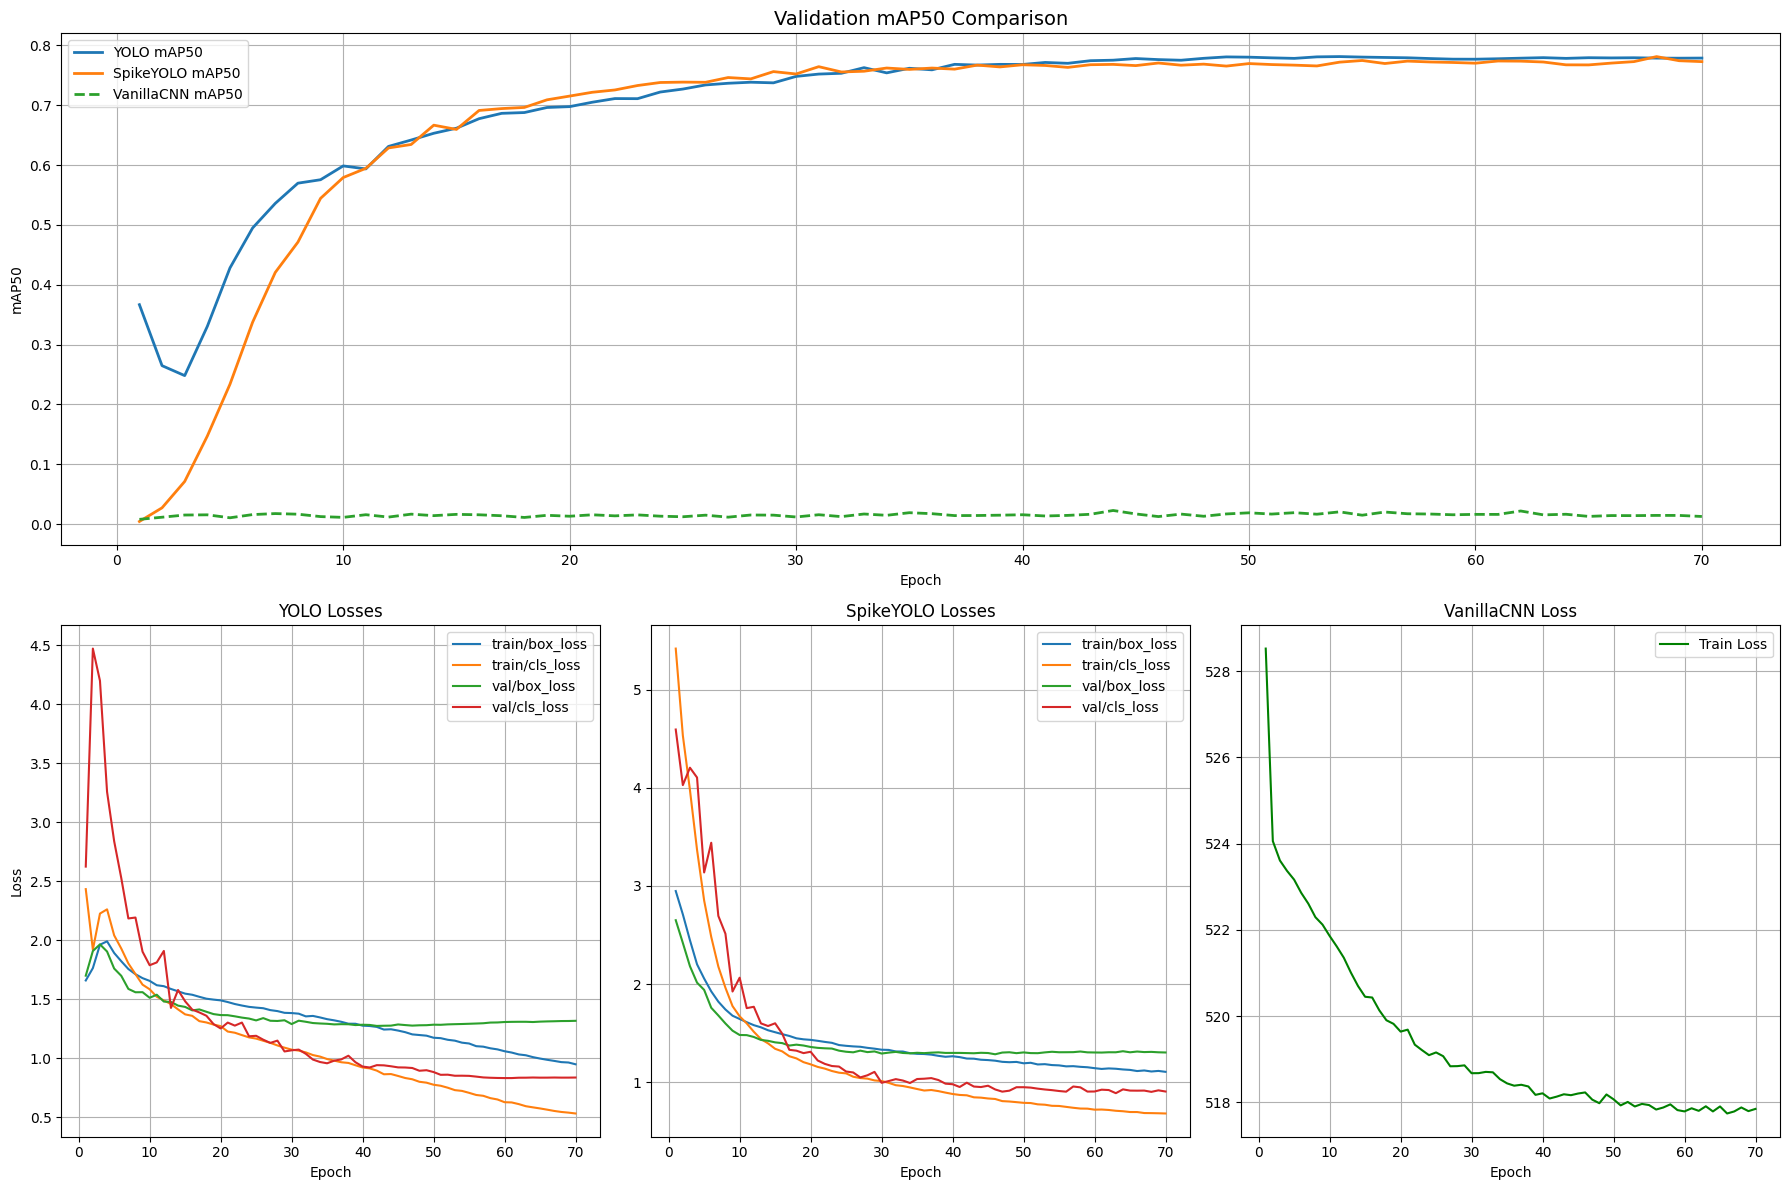

In [2]:
%matplotlib inline
# Define paths
paths = {
    "YOLO": os.path.join("Results", "YOLO", "results_gpu_papa", "results.csv"),
    "SpikeYOLO": os.path.join("Results", "SpikeYOLO", "results_gpu_papa", "results.csv"),
    "VanillaCNN": os.path.join("Results", "VanillaCNN", "D-Fire", "vanilla_cnn_results.csv")
}
# Load data
dfs = {}
for name, path in paths.items():
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)
            # Strip whitespace from column names
            
            df.columns = df.columns.str.strip()
            dfs[name] = df
            print(f"Loaded {name} with {len(df)} epochs.")
        except Exception as e:
            print(f"Failed to load {name}: {e}")
    else:
        print(f"File not found for {name}: {path}")
# Setup figure
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3)
# --- 1. mAP50 Comparison ---
ax_map = fig.add_subplot(gs[0, :])  # Span all columns in first row
ax_map.set_title("Validation mAP50 Comparison", fontsize=14)
ax_map.set_xlabel("Epoch")
ax_map.set_ylabel("mAP50")
ax_map.grid(True)
for name, df in dfs.items():
    if name == "YOLO" or name == "SpikeYOLO":
        if 'metrics/mAP50(B)' in df.columns:
            ax_map.plot(df['epoch'], df['metrics/mAP50(B)'], label=f"{name} mAP50", linewidth=2)
    elif name == "VanillaCNN":
        if 'mAP50' in df.columns:
            # VanillaCNN usually starts later or has different epoch alignment, plotting as is
            ax_map.plot(df['epoch'], df['mAP50'], label=f"{name} mAP50", linewidth=2, linestyle='--')
ax_map.legend()
# --- 2. Loss Plots (Row 2) ---
# YOLO Loss
ax_loss_yolo = fig.add_subplot(gs[1, 0])
if "YOLO" in dfs:
    df = dfs["YOLO"]
    columns_to_plot = ['train/box_loss', 'train/cls_loss', 'val/box_loss', 'val/cls_loss']
    for col in columns_to_plot:
        if col in df.columns:
            ax_loss_yolo.plot(df['epoch'], df[col], label=col)
    ax_loss_yolo.set_title("YOLO Losses")
    ax_loss_yolo.set_xlabel("Epoch")
    ax_loss_yolo.set_ylabel("Loss")
    ax_loss_yolo.legend()
    ax_loss_yolo.grid(True)
# SpikeYOLO Loss
ax_loss_spike = fig.add_subplot(gs[1, 1])
if "SpikeYOLO" in dfs:
    df = dfs["SpikeYOLO"]
    columns_to_plot = ['train/box_loss', 'train/cls_loss', 'val/box_loss', 'val/cls_loss']
    for col in columns_to_plot:
        if col in df.columns:
            ax_loss_spike.plot(df['epoch'], df[col], label=col)
    ax_loss_spike.set_title("SpikeYOLO Losses")
    ax_loss_spike.set_xlabel("Epoch")
    ax_loss_spike.legend()
    ax_loss_spike.grid(True)
# VanillaCNN Loss
ax_loss_vanilla = fig.add_subplot(gs[1, 2])
if "VanillaCNN" in dfs:
    df = dfs["VanillaCNN"]
    if 'train_loss' in df.columns:
        ax_loss_vanilla.plot(df['epoch'], df['train_loss'], label='Train Loss', color='green')
    ax_loss_vanilla.set_title("VanillaCNN Loss")
    ax_loss_vanilla.set_xlabel("Epoch")
    ax_loss_vanilla.legend()
    ax_loss_vanilla.grid(True)
plt.tight_layout()
plt.show()

# SPIKE YOLO

## Visualization SpikeYOLO Training Results

## Visualization SpikeYOLO Test Results

# YOLOv8L

## Visualization Yolov8l Training Results


## Visualization Yolov8l Test Results


# CNN

## Visualization VanillaCNN Training Results

## Visualization VanillaCNN Testing Results

# MODEL COMPARISON

## Comparison All Models

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ============================================================
# 1) CONFIG
# ============================================================

RUNS = [
    {
        "name": "Vanilla CNN",
        "path": None,
        "cols": {
            "epoch": "epoch",
            "map50": "mAP50", 
            # "precision": "...",
            # "recall": "...",
            # "map5095": "...",
        },
    },
    {
        "name": "SpikeYolo",
        "path": "Results\SpikeYOLO\results_gpu_papa\results.csv",  # e.g. "/content/drive/MyDrive/TFM/Results/SpikeYolo/results.csv"
        "cols": {
            "epoch": "epoch",
            "map50": "mAP50",          # set to correct column in your CSV
            # Uncomment/adjust these if you have them:
            # "precision": "precision",
            # "recall": "recall",
            # "map5095": "mAP50-95",
        },
    },
    {
        "name": "YOLOv8l",
        "path": None,
        "cols": {
            "epoch": "epoch",
            "map50": "metrics/mAP50(B)",       # YOLOv8 mAP@0.5
            "precision": "metrics/precision(B)",
            "recall": "metrics/recall(B)",
            "map5095": "metrics/mAP50-95(B)",
        },
    },
]


# ============================================================
# 2) Helper: load & standardize metrics for one model
#    Required: epoch, map50
#    Optional: precision, recall, map5095
# ============================================================
def load_model_metrics(name, path, col_map):
    path = Path(path)
    if not path.exists():
        print(f"Skipping {name}: file not found at {path}")
        return None

    df = pd.read_csv(path)

    # Required columns
    if col_map["epoch"] not in df.columns:
        print(f"Skipping {name}: epoch column '{col_map['epoch']}' not in {list(df.columns)}")
        return None
    if col_map["map50"] not in df.columns:
        print(f"Skipping {name}: mAP50 column '{col_map['map50']}' not in {list(df.columns)}")
        return None

    out = pd.DataFrame()
    out["epoch"] = df[col_map["epoch"]]
    out["mAP50"] = df[col_map["map50"]]
    out["model"] = name

    # Optional metrics
    for logical_name in ["precision", "recall", "map5095"]:
        colname = col_map.get(logical_name, None)
        if colname is not None and colname in df.columns:
            out[logical_name] = df[colname]
        else:
            out[logical_name] = pd.NA  # fill with NaN if not available

    return out


# ============================================================
# 3) Load all available runs (1, 2 or 3)
# ============================================================
models_data = {}

for run in RUNS:
    name = run["name"]
    path = run["path"]
    cols = run["cols"]

    if path is None:
        print(f"Skipping {name}: path is None")
        continue

    print(f"Loading metrics for {name}...")
    df_model = load_model_metrics(name, path, cols)
    if df_model is not None:
        models_data[name] = df_model

if not models_data:
    raise RuntimeError("No valid result files loaded. Check paths and column mappings.")

all_metrics_df = pd.concat(models_data.values(), ignore_index=True)
print("\nCombined metrics (first rows):")
display(all_metrics_df.head())


# ============================================================
# 4) PLOTS — only good comparable metrics
# ============================================================

# ---------- Plot 1: mAP@0.5 vs epoch ----------
plt.figure(figsize=(8, 5))
for name, df in models_data.items():
    plt.plot(df["epoch"], df["mAP50"], marker="o", label=name)

plt.title("mAP@0.5 vs epoch")
plt.xlabel("Epoch")
plt.ylabel("mAP@0.5")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# ---------- Plot 2: Final mAP@0.5 comparison ----------
final_rows = []
for name, df in models_data.items():
    last = df.iloc[-1]
    final_rows.append({
        "model": name,
        "final_mAP50": last["mAP50"],
        "final_precision": last.get("precision", pd.NA),
        "final_recall": last.get("recall", pd.NA),
        "final_mAP50-95": last.get("map5095", pd.NA),
    })

final_df = pd.DataFrame(final_rows).set_index("model")
print("\nFinal-epoch summary (only good metrics):")
display(final_df)

# Bar for mAP50
plt.figure(figsize=(6, 4))
plt.bar(final_df.index, final_df["final_mAP50"])
plt.title("Final mAP@0.5 comparison")
plt.ylabel("mAP@0.5")
plt.tight_layout()
plt.show()


# ---------- Optional: precision / recall / mAP50-95 bars if available ----------

def plot_if_available(metric_col, title, ylabel):
    # Drop models where this metric is NaN
    sub = final_df[metric_col].dropna()
    if sub.empty:
        return
    plt.figure(figsize=(6, 4))
    plt.bar(sub.index, sub.values)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

plot_if_available("final_precision", "Final precision comparison", "Precision")
plot_if_available("final_recall", "Final recall comparison", "Recall")
plot_if_available("final_mAP50-95", "Final mAP@0.5:0.95 comparison", "mAP@0.5:0.95")

Skipping Vanilla CNN: path is None
Loading metrics for SpikeYolo...
esults.csv_papaolo: file not found at Results\SpikeYOLO
Skipping YOLOv8l: path is None


RuntimeError: No valid result files loaded. Check paths and column mappings.

## Comparison YOLO Models

Loaded metric files:


{'SpikeYolo':                      epoch           train/box_loss           train/cls_loss  \
 0                        1                   2.9479                   5.4170   
 1                        2                   2.7104                   4.5320   
 2                        3                   2.4476                   3.9768   
 3                        4                   2.2017                   3.3676   
 4                        5                   2.0568                   2.8515   
 
             train/dfl_loss     metrics/precision(B)        metrics/recall(B)  \
 0                   2.9378                  0.00124                  0.35323   
 1                   2.7298                  0.00341                  0.47860   
 2                   2.4708                  0.59795                  0.10618   
 3                   2.2295                  0.27267                  0.21743   
 4                   2.0428                  0.36894                  0.27925   
 
           

Final epoch comparison:


,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,...,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
model,,,,,,,,,,,,,,,,,,,,,
SpikeYolo,70.0,1.107,0.68288,1.216,0.77536,0.72541,0.77295,0.46186,1.304,0.90656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YOLOv8l,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.76317,0.74663,0.77889,0.46432,1.31624,0.83527,1.35459,0.000241,0.000241,0.000241


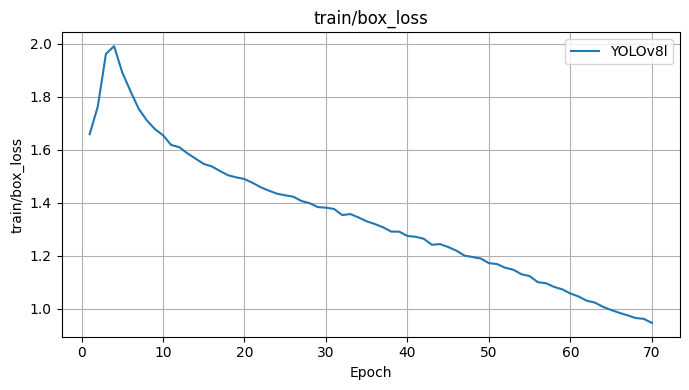

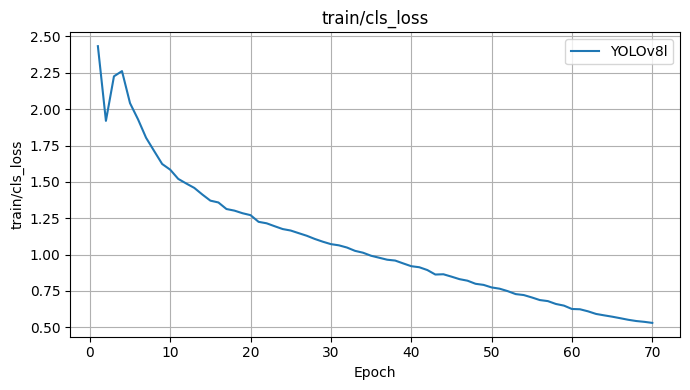

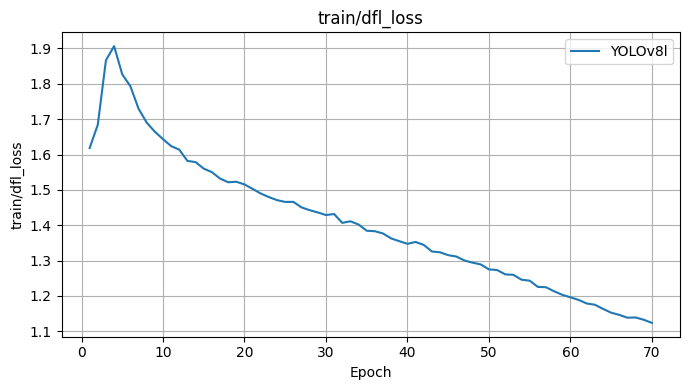

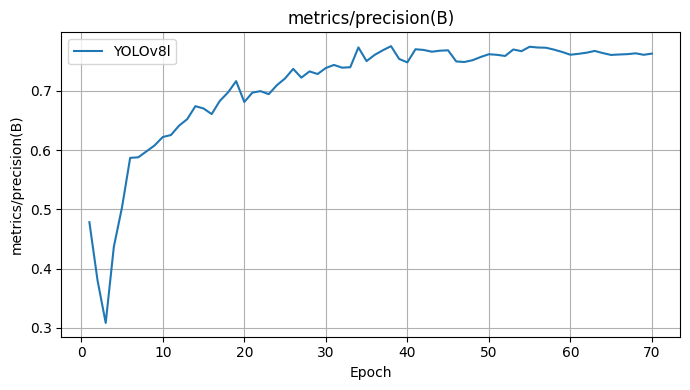

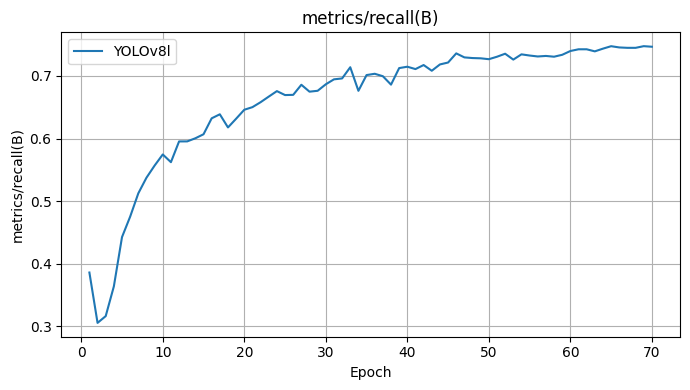

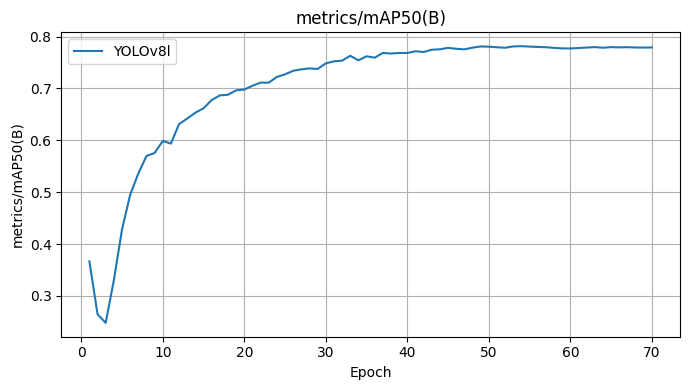

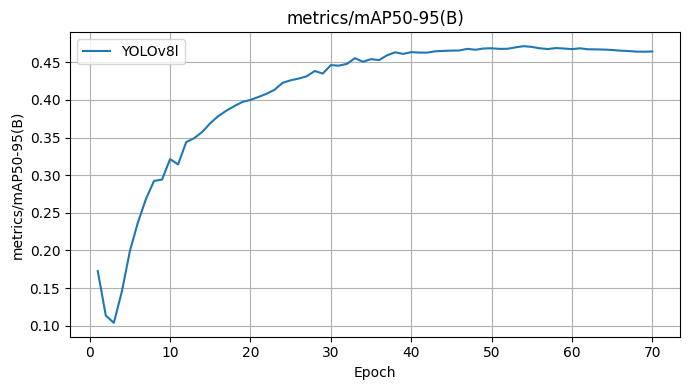

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

SPIKEYOLO_CSV = Path("C:/Users/paubu/Desktop/Master/Setembre 2025 - Gener 2026/TFM/Code/Results/SpikeYOLO/results_gpu_papa/results.csv")

YOLOV8_CSV = Path("C:/Users/paubu/Desktop/Master/Setembre 2025 - Gener 2026/TFM/Code/Results/YOLO/results_gpu_papa/results.csv")


MODEL_NAMES = {
    "SpikeYolo": SPIKEYOLO_CSV,
    "YOLOv8l" : YOLOV8_CSV,
}

data = {}
for name, path in MODEL_NAMES.items():
    if not Path(path).exists():
        raise FileNotFoundError(f"Training metrics file not found: {path}")
    df = pd.read_csv(path)
    data[name] = df

print("Loaded metric files:")
display({name: df.head() for name, df in data.items()})

# --------------------------------------------------------
# 3) Build a final-epoch comparison table
# --------------------------------------------------------

summary_rows = []

for name, df in data.items():
    last = df.iloc[-1].copy()
    last["model"] = name
    summary_rows.append(last)

summary_df = pd.DataFrame(summary_rows).set_index("model")

print("Final epoch comparison:")
display(summary_df)

# --------------------------------------------------------
# 4) Plot metric curves (loss, mAP, precision, recall…)
# --------------------------------------------------------

# Choose which metrics to visualize
PLOT_METRICS = [
    "train/box_loss", "train/cls_loss", "train/dfl_loss",
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)"
]

# Plot each metric across both models
for metric in PLOT_METRICS:
    plt.figure(figsize=(7,4))
    for name, df in data.items():
        if metric in df.columns:
            plt.plot(df["epoch"], df[metric], label=name)
    plt.title(metric)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# CODE CARBON


## Comparison CodeCarbon Results Training

In [ ]:
algorithms = [
    {
        "name": "Vanilla CNN",
        "path": "/content/drive/MyDrive/TFM/Results/Vanilla_CNN/vanilla_cnn_emissions.csv",
    },
    {
        "name": "YoloV8l",
        "path": "/content/drive/MyDrive/TFM/Results/YoloV8l/yolov8l_emissions.csv",
    },
]

# --------------------------------------------------------
#SUMMARY TABLE
# --------------------------------------------------------

rows = []

for alg in algorithms:
    if alg["path"] is None:
        continue

    csv_path = Path(alg["path"])
    if not csv_path.exists():
        print(f" File not found, skipping: {csv_path}")
        continue

    df = pd.read_csv(csv_path)

    row = df.iloc[0]

    duration = row["duration"]                 # seconds
    energy = row["energy_consumed"]           # kWh (CodeCarbon default)
    emissions = row["emissions"]              # kg CO₂eq

    avg_power_w = energy * 1000 / duration if duration > 0 else float("nan")

    rows.append({
        "Algorithm": alg["name"],
        "Duration [s]": duration,
        "Energy [kWh]": energy,
        "Emissions [kg CO₂eq]": emissions,
        "Emissions rate [kg/s]": row.get("emissions_rate", float("nan")),
        "CPU energy [kWh]": row.get("cpu_energy", float("nan")),
        "GPU energy [kWh]": row.get("gpu_energy", float("nan")),
        "RAM energy [kWh]": row.get("ram_energy", float("nan")),
        "Water consumed [L]": row.get("water_consumed", float("nan")),
        "Avg power [W]": avg_power_w,
        "PUE": row.get("pue", float("nan")),
        "WUE": row.get("wue", float("nan")),
        "CPU model": row.get("cpu_model", ""),
        "GPU model": row.get("gpu_model", ""),
    })

comparison_df = pd.DataFrame(rows).set_index("Algorithm")

# --------------------------------------------------------
# 3) SHOW THE TABLE
# --------------------------------------------------------
print("Comparison of algorithms (training runs):")
display(comparison_df)


Comparison of algorithms (training runs):


,Duration [s],Energy [kWh],Emissions [kg CO₂eq],Emissions rate [kg/s],CPU energy [kWh],GPU energy [kWh],RAM energy [kWh],Water consumed [L],Avg power [W],PUE,WUE,CPU model,GPU model
Algorithm,,,,,,,,,,,,,
Vanilla CNN,764.61958,0.011150,0.005047,0.000007,0.009026,0.0,0.002124,0.0,0.014583,1.0,0.0,Intel(R) Xeon(R) CPU @ 2.20GHz,NaN
YoloV8l,4157.03600,0.060621,0.027439,0.000007,0.049075,0.0,0.011546,0.0,0.014583,1.0,0.0,Intel(R) Xeon(R) CPU @ 2.20GHz,NaN


## Comparison CodeCarbon Testing Results

# TESTING ALGORITHMS WITH SIMULATED REAL-TIME SITUATIONS (VIDEOS)

## SpikeYOLO Testing

## YoloV8l Testing

## VanillaCNN Testing

# COMPARISON OF THE RESULTS

## Metrics Comparison

## CodeCarbon Comparison

# RENDER VIDEO

In [ ]:
# Video Inference Setup
import sys
import os

# Ensure the current directory is in the path to find the new module
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

from video_render.video_inference import process_and_display_video

# === CONFIGURATION ===
# Replace with the path to your trained model or a pretrained one (e.g. 'yolov8l.pt')
model_path = 'yolov8l.pt' 

# Replace with the path to the video you want to test
video_path = 'path/to/your/video.mp4' 

# Run Real-Time Inference in Notebook Cell
if os.path.exists(video_path):
    process_and_display_video(model_path, video_path, conf_threshold=0.25)
else:
    print(f"Video file not found: {video_path}")
    print("Please update the 'video_path' variable to point to your video file.")